# Regional Risk Model — LightGBM + SHAP
### نموذج المخاطر الإقليمي

**Notebook:** `03_regional_risk.ipynb`
**Author:** Khalid Al-Dosari ([@khaliddosari](https://github.com:443/khaliddosari/saudi-road-safety-mlops))
**Project:** [saudi-road-safety-mlops](https://github.com/khaliddosari/saudi-road-safety-mlops)

---

## Objectives

Model **exposure-adjusted fatality risk** across Saudi Arabia's 13 administrative regions, 2020 – 2024.

- **Target:** `deaths_per_1k_vehicles` — the exposure-adjusted rate that the EDA showed is the *policy-relevant* signal (Tabuk / Jazan paradox). Raw death counts reward population size, not road-safety performance.
- **Model:** LightGBM gradient boosting.
- **Explainability:** SHAP — global feature importance plus per-region waterfalls, so every regional risk score can be defended in a policy memo.
- **Validation:** **Leave-One-Group-Out** by region. Each fold holds out a whole region (all 5 years), and the model is trained on the remaining 12. This is the only honest way to answer "could we predict risk for a region we haven't modeled yet?" on a 65-row panel.

### Why this matters

The project thesis is that official reporting over-weights raw counts, which maps policy attention onto the wrong regions. This notebook quantifies that gap by showing **which regional features drive exposure-adjusted risk**, not which regions happen to have the most traffic.

### Sample-size honesty

n = 65 is small. This notebook is designed to demonstrate a **reproducible, explainable, leakage-free** regional-risk pipeline — not to claim a world-class regression. Hyperparameters are kept conservative (shallow trees, high `min_data_in_leaf`) so the model generalizes rather than memorizes.

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
PROCESSED = REPO_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 42
RNG = np.random.default_rng(SEED)

print("Repo root :", REPO_ROOT)
print("Processed :", PROCESSED)

Repo root : c:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops
Processed : c:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops\data\processed


c:\Users\Khalid\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
panel = pd.read_csv(PROCESSED / "regional_panel.csv").sort_values(["region", "year"]).reset_index(drop=True)

print(f"Panel shape : {panel.shape}")
print(f"Regions     : {panel['region'].nunique()}")
print(f"Years       : {panel['year'].min()} – {panel['year'].max()}")
panel.head()

Panel shape : (65, 20)
Regions     : 13
Years       : 2020 – 2024


,region,year,injuries,deaths,severe_in_city,severe_out_city,severe_total,vehicles_new,vehicles_renewal,licenses_new,licenses_renewal,road_density_per_capita,road_density_per_area,vehicles_total,licenses_total,deaths_per_1k_vehicles,injuries_per_1k_vehicles,severe_per_1k_vehicles,fatality_ratio,region_ar
0,Al-Baha,2020,628.000,95.000,NaN,NaN,NaN,1193,16970,5843,3447,NaN,NaN,18163,9290,5.230,34.576,NaN,0.131,الباحة
1,Al-Baha,2021,565.000,92.000,NaN,NaN,388.000,1325,10724,8336,2337,NaN,NaN,12049,10673,7.635,46.892,32.202,0.140,الباحة
2,Al-Baha,2022,526.000,98.000,NaN,NaN,344.000,1041,11010,13075,1675,NaN,NaN,12051,14750,8.132,43.648,28.545,0.157,الباحة
3,Al-Baha,2023,500.000,67.000,NaN,NaN,301.000,1279,11837,11747,1454,NaN,NaN,13116,13201,5.108,38.121,22.949,0.118,الباحة
4,Al-Baha,2024,551.000,61.000,146.000,201.000,347.000,1577,12571,12512,1791,0.020,0.643,14148,14303,4.312,38.945,24.526,0.100,الباحة


## 1. Feature prep and leakage audit | إعداد المتغيرات والتحقق من التسرّب

The panel has 20 columns but many of them would **leak the target** if used as features. A formal audit:

| Column | Uses `deaths`? | Valid feature? |
|---|---|---|
| `deaths` | target numerator | ❌ target only |
| `deaths_per_1k_vehicles` | target | ❌ **target** |
| `fatality_ratio = deaths / (deaths + injuries)` | yes | ❌ leakage |
| `injuries` | no | ✅ (but correlated) |
| `severe_total`, `severe_in_city`, `severe_out_city` | no | ✅ (partial coverage) |
| `injuries_per_1k_vehicles` | no | ✅ exposure-adjusted, independent |
| `severe_per_1k_vehicles` | no | ✅ exposure-adjusted, independent |
| `vehicles_total`, `vehicles_new`, `vehicles_renewal` | no | ✅ exposure base |
| `licenses_total`, `licenses_new`, `licenses_renewal` | no | ✅ driver supply |
| `road_density_per_capita`, `road_density_per_area` | no | ✅ (2024 only → LightGBM handles NaN) |
| `year` | no | ✅ trend control |
| `region`, `region_ar` | no | ⚠️ identity — **exclude** (LOGO makes it non-generalizing) |

LightGBM handles missing values natively, so sparse columns like `severe_*` (2021+) and `road_density_*` (2024 only) are kept — LightGBM learns a default direction for the missing branch.

In [3]:
TARGET = "deaths_per_1k_vehicles"

# Explicit exclusion lists — documenting *why* each column is dropped is the point
TARGET_COLS = ["deaths", "deaths_per_1k_vehicles"]
LEAKAGE_COLS = ["fatality_ratio"]                                  # uses deaths in numerator
IDENTITY_COLS = ["region", "region_ar"]                             # held out by LOGO → would not generalize
RAW_INJURIES = ["injuries"]                                         # drop raw count in favor of exposure-adjusted version
RAW_SEVERE = ["severe_total", "severe_in_city", "severe_out_city"]  # drop raw counts; keep exposure-adjusted

DROP = TARGET_COLS + LEAKAGE_COLS + IDENTITY_COLS + RAW_INJURIES + RAW_SEVERE

FEATURES = [c for c in panel.columns if c not in DROP]

# We keep year as a continuous feature (trend), not a group — LOGO groups are regions
X = panel[FEATURES].copy()
y = panel[TARGET].astype(float).copy()
groups = panel["region"].copy()

# Guard: the target should not be derivable from features (no column whose values equal y)
_leak_check = [c for c in FEATURES if np.allclose(X[c].fillna(-999), y.fillna(-999), atol=1e-6)]
assert not _leak_check, f"Potential leakage: {_leak_check}"

print(f"Target    : {TARGET}")
print(f"n_samples : {len(X)}")
print(f"n_features: {X.shape[1]}")
print(f"Features  : {FEATURES}")
print(f"\nMissingness per feature (LightGBM handles internally):")
print(X.isna().sum().to_string())

Target    : deaths_per_1k_vehicles
n_samples : 65
n_features: 11
Features  : ['year', 'vehicles_new', 'vehicles_renewal', 'licenses_new', 'licenses_renewal', 'road_density_per_capita', 'road_density_per_area', 'vehicles_total', 'licenses_total', 'injuries_per_1k_vehicles', 'severe_per_1k_vehicles']

Missingness per feature (LightGBM handles internally):
year                         0
vehicles_new                 0
vehicles_renewal             0
licenses_new                 0
licenses_renewal             0
road_density_per_capita     52
road_density_per_area       52
vehicles_total               0
licenses_total               0
injuries_per_1k_vehicles     0
severe_per_1k_vehicles      13


## 2. Validation strategy — Leave-One-Group-Out by region | استراتيجية التحقق

With 13 regions × 5 years, random K-fold would happily put Riyadh 2020 in train and Riyadh 2024 in test — the model would just memorize Riyadh's level and pose as a forecaster. **Leave-One-Group-Out by region** forces the honest question: *can the model estimate risk for a region it has never seen in training?*

Each of the 13 folds holds out all 5 rows of one region and trains on the remaining 60. We report the pooled metrics across all folds (each sample predicted exactly once out-of-fold). This produces **region-generalization** estimates, which is what we actually need for deployment — the BI dashboard should still work when a new region-year arrives next year.

In [4]:
def score(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def logo_predict(
    model_factory,
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Leave-One-Group-Out: returns (oof_preds, per_fold_metrics)."""
    logo = LeaveOneGroupOut()
    oof = np.full(len(y), np.nan)
    fold_rows = []
    for fold, (tr, te) in enumerate(logo.split(X, y, groups)):
        model = model_factory()
        if isinstance(model, lgb.LGBMRegressor):
            # Use a few rows from the training fold as an internal eval set for early stopping.
            eval_idx = tr[-5:]
            fit_idx = tr[:-5]
            model.fit(
                X.iloc[fit_idx], y.iloc[fit_idx],
                eval_set=[(X.iloc[eval_idx], y.iloc[eval_idx])],
                callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
            )
        else:
            model.fit(X.iloc[tr], y.iloc[tr])
        oof[te] = model.predict(X.iloc[te])
        held_out_region = groups.iloc[te].iloc[0]
        fold_rows.append({
            "fold": fold,
            "held_out_region": held_out_region,
            "n_test": len(te),
            **score(y.iloc[te].values, oof[te]),
        })
    return oof, pd.DataFrame(fold_rows)


# Groups inventory
group_counts = groups.value_counts().sort_index()
print(f"LOGO folds: {groups.nunique()} (one per region)")
print(f"Rows per region: min={group_counts.min()}, max={group_counts.max()}")

LOGO folds: 13 (one per region)
Rows per region: min=5, max=5


## 3. Baselines — global mean & Ridge regression | النماذج الأساسية

Two baselines every LightGBM regional-risk paper should beat:

- **Global mean** — predict the overall training-fold mean of `deaths_per_1k_vehicles` for every held-out row. If LightGBM barely beats this, we're overfitting to noise.
- **Ridge regression** — standardized linear model with L2. Interpretable, stable on small n, strong on near-linear signals. On tabular data with ~60 rows it is often genuinely hard to beat.

In [5]:
class MeanRegressor:
    """Predicts the training-fold mean of y for every row."""
    def fit(self, X, y):
        self.mean_ = float(np.mean(y))
        return self

    def predict(self, X):
        return np.full(len(X), self.mean_)


def make_ridge() -> Pipeline:
    # Ridge needs imputation + scaling on this feature set
    from sklearn.impute import SimpleImputer
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=SEED)),
    ])


mean_oof, mean_folds = logo_predict(MeanRegressor, X, y, groups)
ridge_oof, ridge_folds = logo_predict(make_ridge, X, y, groups)

baseline_summary = pd.DataFrame({
    "Mean baseline": score(y.values, mean_oof),
    "Ridge":         score(y.values, ridge_oof),
}).T.round(3)
print("Out-of-fold metrics (13-fold LOGO):")
print(baseline_summary.to_string())

Out-of-fold metrics (13-fold LOGO):
                mae  rmse     r2
Mean baseline 1.961 2.293 -0.143
Ridge         1.502 1.787  0.306


## 4. LightGBM with region-generalization CV | نموذج لايت جي بي إم

Conservative hyperparameters for a 65-row panel:

- `num_leaves = 15`, `max_depth = 4` — shallow trees
- `min_data_in_leaf = 3` — n is tiny, but under 3 each leaf becomes a single region-year
- `learning_rate = 0.05` with `n_estimators = 500` — let early stopping pick the actual tree count
- `feature_fraction = 0.85`, `bagging_fraction = 0.85` — mild randomization
- `reg_lambda = 1.0` — L2 regularization
- `objective = 'regression_l1'` — L1 loss is robust to the one big outlier year per region

No per-region embedding: LOGO would render it meaningless.

In [6]:
LGB_PARAMS = dict(
    objective="regression_l1",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=4,
    min_data_in_leaf=3,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=-1,
)


def make_lgbm() -> lgb.LGBMRegressor:
    return lgb.LGBMRegressor(**LGB_PARAMS)


lgbm_oof, lgbm_folds = logo_predict(make_lgbm, X, y, groups)

summary = pd.DataFrame({
    "Mean baseline": score(y.values, mean_oof),
    "Ridge":         score(y.values, ridge_oof),
    "LightGBM":      score(y.values, lgbm_oof),
}).T.round(3)
print("Out-of-fold metrics (13-fold LOGO):")
print(summary.to_string())

# Per-fold LightGBM error — which regions is the model genuinely generalizing to?
print("\nLightGBM per-fold (held-out region):")
print(lgbm_folds.sort_values("mae").round(3).to_string(index=False))

Out-of-fold metrics (13-fold LOGO):
                mae  rmse     r2
Mean baseline 1.961 2.293 -0.143
Ridge         1.502 1.787  0.306
LightGBM      1.218 1.530  0.491

LightGBM per-fold (held-out region):
 fold  held_out_region  n_test   mae  rmse      r2
   11           Riyadh       5 0.207 0.250  -0.339
    4             Hail       5 0.609 0.621   0.577
    8           Najran       5 0.636 0.708   0.715
    9 Northern Borders       5 0.760 0.928  -0.248
    1          Al-Jouf       5 0.804 0.830   0.057
    3          Eastern       5 0.817 0.819 -58.300
   10           Qassim       5 0.847 0.895  -3.175
    0          Al-Baha       5 1.157 1.355   0.197
    6          Madinah       5 1.345 1.349  -3.023
    7           Makkah       5 1.422 1.439 -17.152
   12            Tabuk       5 1.730 1.853 -12.281
    5            Jazan       5 2.713 3.070  -2.470
    2            Aseer       5 2.781 2.806 -16.677


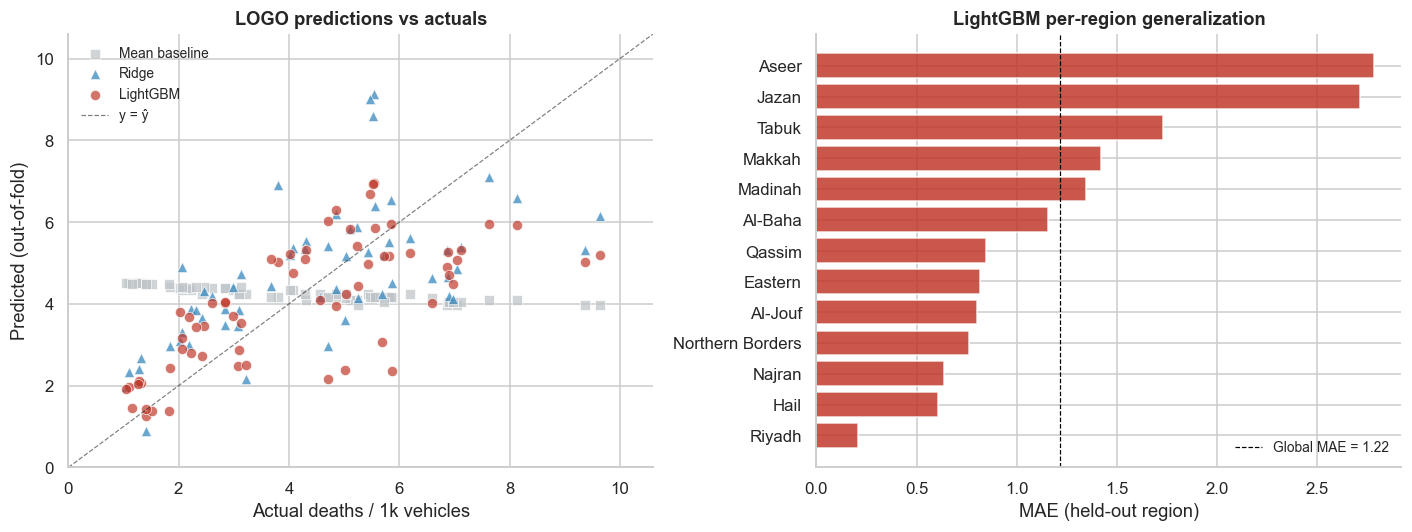

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual ------------------------------------------------------
for oof, name, color, marker in [
    (mean_oof, "Mean baseline", "#bdc3c7", "s"),
    (ridge_oof, "Ridge", "#2980b9", "^"),
    (lgbm_oof, "LightGBM", "#c0392b", "o"),
]:
    ax1.scatter(y, oof, alpha=0.7, s=45, color=color, label=name, marker=marker, edgecolor="white", linewidth=0.6)
lims = [0, max(y.max(), np.nanmax(lgbm_oof)) * 1.1]
ax1.plot(lims, lims, ls="--", color="black", lw=0.8, alpha=0.5, label="y = ŷ")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("Actual deaths / 1k vehicles")
ax1.set_ylabel("Predicted (out-of-fold)")
ax1.set_title("LOGO predictions vs actuals")
ax1.legend(frameon=False, fontsize=9, loc="upper left")

# Per-region LightGBM MAE --------------------------------------------------
fold_sorted = lgbm_folds.sort_values("mae")
ax2.barh(fold_sorted["held_out_region"], fold_sorted["mae"], color="#c0392b", alpha=0.85)
ax2.axvline(summary.loc["LightGBM", "mae"], ls="--", color="black", lw=0.8,
            label=f"Global MAE = {summary.loc['LightGBM', 'mae']:.2f}")
ax2.set_xlabel("MAE (held-out region)")
ax2.set_title("LightGBM per-region generalization")
ax2.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## 5. SHAP — global importance + regional waterfalls | قيم شابلي للتفسير

SHAP values decompose each prediction into additive feature contributions. For this project they answer two questions:

1. **Global** — across all region-years, which features drive the exposure-adjusted risk estimate?
2. **Regional** — for a specific region-year (e.g. Tabuk 2024), *why* did the model predict that risk level? This is what a policy brief needs.

We train a final model on the full panel for SHAP, then compute values with `shap.TreeExplainer` (fast, exact for tree models).

In [8]:
# Fit final model on the full panel. We drop early-stopping (no held-out set here);
# n_estimators is capped at the median of the CV-selected best iterations as a mild guard.
best_iters = []
logo = LeaveOneGroupOut()
for tr, _te in logo.split(X, y, groups):
    m = make_lgbm()
    eval_idx = tr[-5:]
    fit_idx = tr[:-5]
    m.fit(X.iloc[fit_idx], y.iloc[fit_idx],
          eval_set=[(X.iloc[eval_idx], y.iloc[eval_idx])],
          callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
    best_iters.append(m.best_iteration_ or m.n_estimators_)

final_n_estimators = int(np.median(best_iters))
print(f"CV best iterations: median={final_n_estimators}, range=({min(best_iters)}, {max(best_iters)})")

final_model = lgb.LGBMRegressor(**{**LGB_PARAMS, "n_estimators": final_n_estimators})
final_model.fit(X, y)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)
print(f"SHAP values shape: {shap_values.shape}")

CV best iterations: median=76, range=(51, 132)
SHAP values shape: (65, 11)


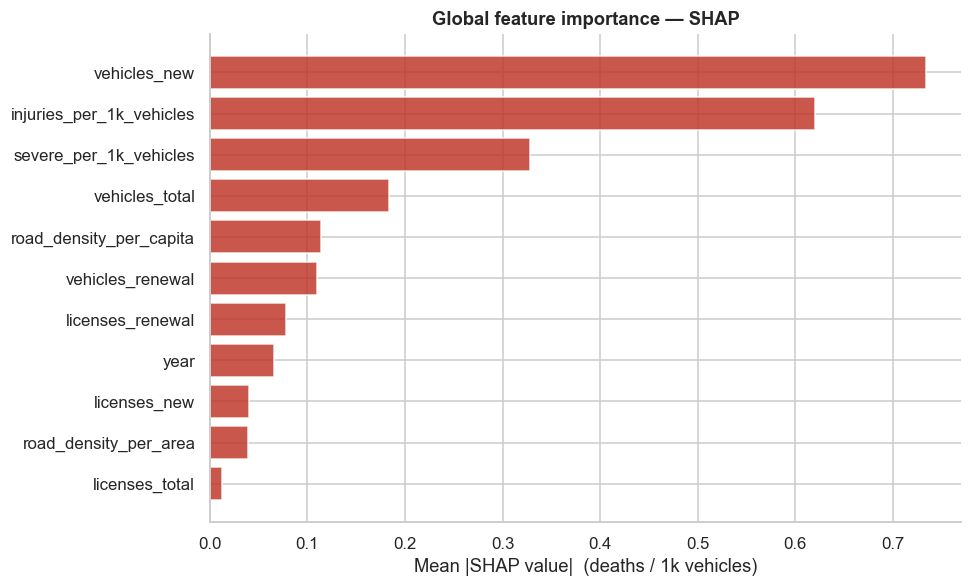

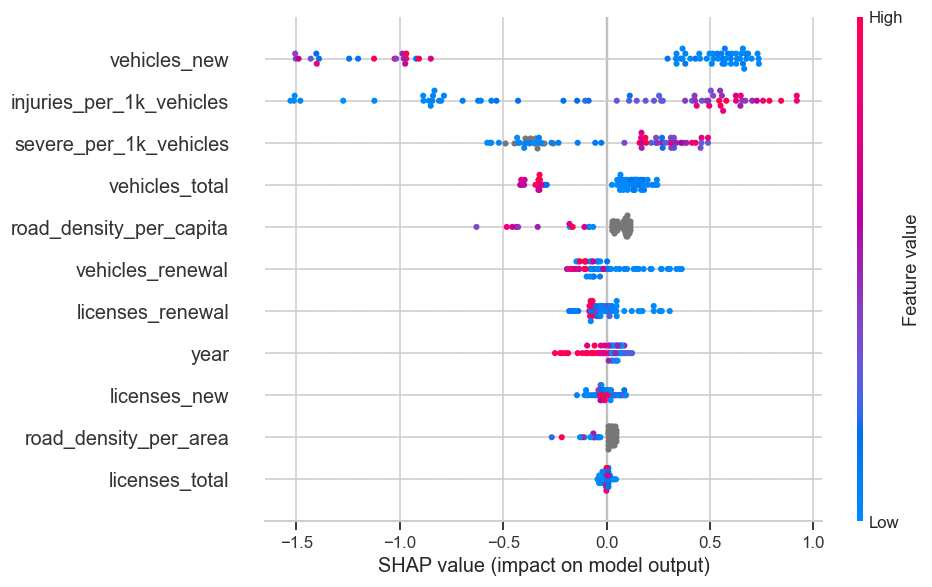


Global SHAP importance (sorted):
                 feature  mean_abs_shap  lgbm_gain_importance  shap_share
            vehicles_new          0.734               505.519      31.542
injuries_per_1k_vehicles          0.621               438.799      26.684
  severe_per_1k_vehicles          0.328               327.043      14.092
          vehicles_total          0.184               126.783       7.905
 road_density_per_capita          0.114               113.497       4.894
        vehicles_renewal          0.110               146.491       4.740
        licenses_renewal          0.078               137.698       3.371
                    year          0.066                82.738       2.842
            licenses_new          0.040               100.553       1.712
   road_density_per_area          0.039                51.125       1.661
          licenses_total          0.013                25.900       0.556


In [9]:
# Global SHAP importance: mean absolute contribution per feature
global_shap = (pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    "lgbm_gain_importance": final_model.booster_.feature_importance(importance_type="gain"),
}).assign(
    shap_share=lambda d: d["mean_abs_shap"] / d["mean_abs_shap"].sum() * 100,
).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))

# --- Bar chart: mean |SHAP| per feature ----------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(global_shap["feature"][::-1], global_shap["mean_abs_shap"][::-1],
        color="#c0392b", alpha=0.85)
ax.set_xlabel("Mean |SHAP value|  (deaths / 1k vehicles)")
ax.set_title("Global feature importance — SHAP")
plt.tight_layout()
plt.show()

# --- Beeswarm: distribution of SHAP values per feature, colored by value -
# shap.summary_plot manages its own figure, so we let it render standalone.
shap.summary_plot(shap_values, X, feature_names=FEATURES, show=True, plot_size=(9, 5.5))

print("\nGlobal SHAP importance (sorted):")
print(global_shap.round(4).to_string(index=False))


Tabuk 2024  — actual 6.98, predicted 5.71 deaths / 1k vehicles


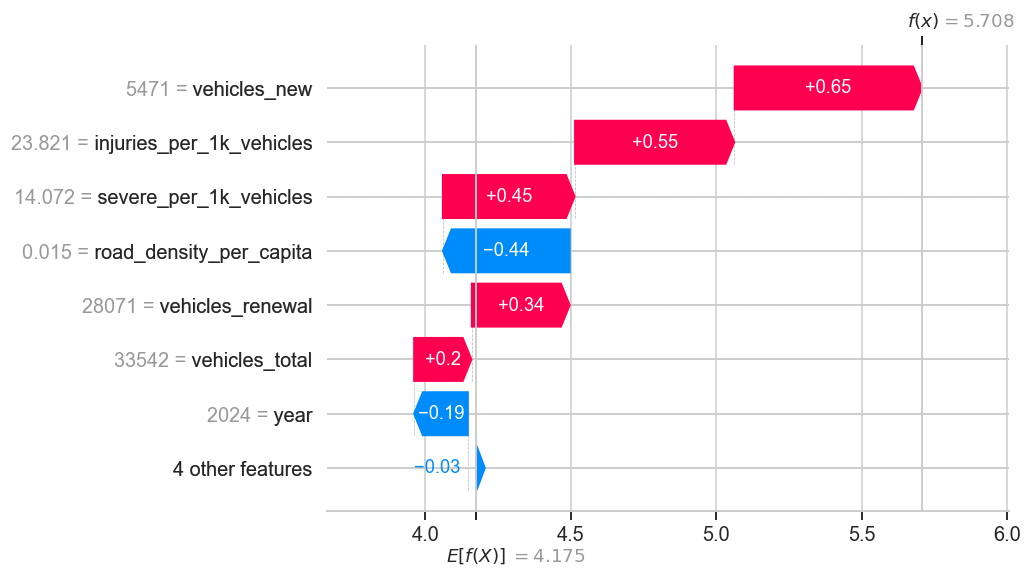


Jazan 2024  — actual 5.26, predicted 5.29 deaths / 1k vehicles


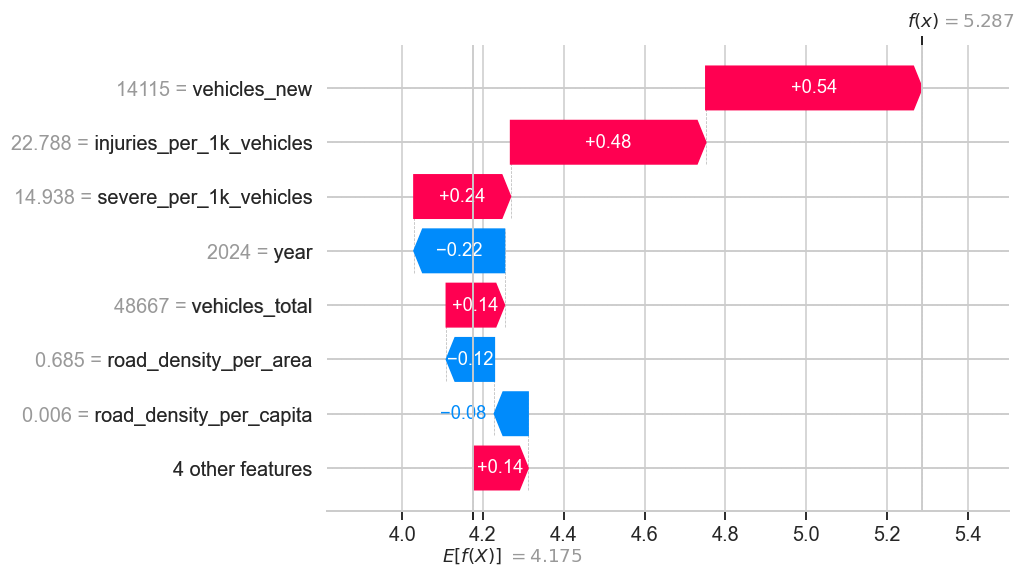


Riyadh 2024  — actual 1.15, predicted 1.45 deaths / 1k vehicles


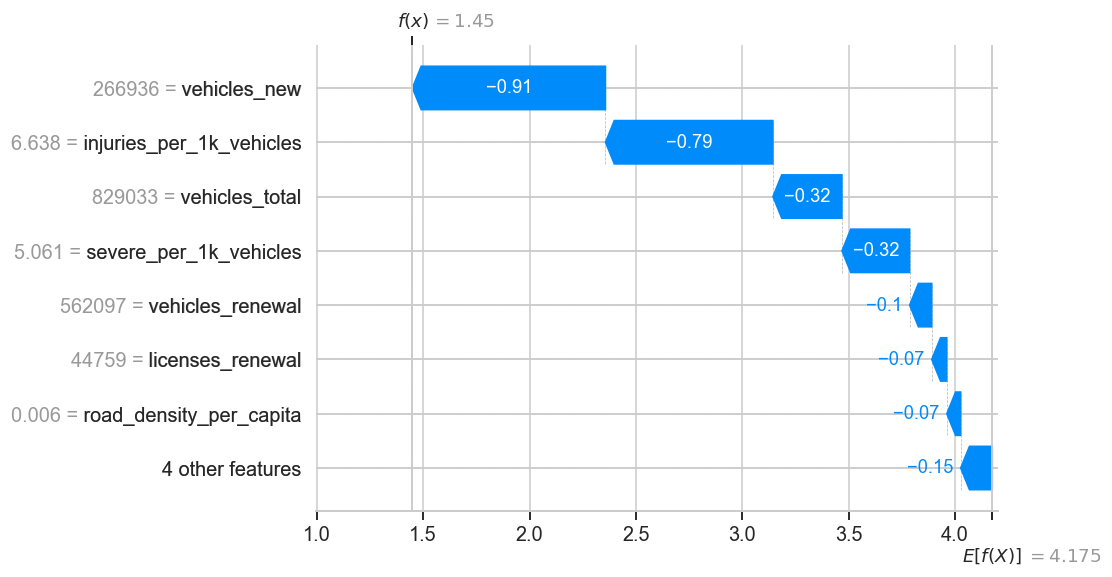

In [10]:
# Regional waterfalls — why did the model land where it did for these region-years?
SPOTLIGHT = [("Tabuk", 2024), ("Jazan", 2024), ("Riyadh", 2024)]

for region, year in SPOTLIGHT:
    idx = panel.index[(panel["region"] == region) & (panel["year"] == year)][0]
    pred = float(final_model.predict(X.iloc[[idx]])[0])
    actual = float(y.iloc[idx])
    print(f"\n{region} {year}  — actual {actual:.2f}, predicted {pred:.2f} deaths / 1k vehicles")
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X.iloc[idx].values,
        feature_names=FEATURES,
    )
    shap.plots.waterfall(explanation, max_display=8, show=True)

## 6. Save risk artifact | حفظ مخرجات النموذج

Write `data/processed/regional_risk.csv` with, for each region-year:

- `actual_risk` and `predicted_risk_oof` (out-of-fold prediction — the honest generalization estimate)
- `predicted_risk_full` (prediction from the full-data model, used for SHAP)
- the top-3 SHAP drivers (feature name + signed contribution)

This is directly consumable by the Power BI dashboard's "Why is this region risky?" tooltip.

In [11]:
def top_shap_features(row_shap: np.ndarray, k: int = 3) -> list[tuple[str, float]]:
    """Return [(feature, signed_shap_value)] sorted by |shap| desc, top-k."""
    order = np.argsort(np.abs(row_shap))[::-1][:k]
    return [(FEATURES[i], float(row_shap[i])) for i in order]


full_preds = final_model.predict(X)

records = []
for i in range(len(panel)):
    top = top_shap_features(shap_values[i], k=3)
    rec = {
        "region": panel.at[i, "region"],
        "region_ar": panel.at[i, "region_ar"],
        "year": int(panel.at[i, "year"]),
        "actual_risk": float(y.iloc[i]),
        "predicted_risk_oof": float(lgbm_oof[i]),
        "predicted_risk_full": float(full_preds[i]),
        "shap_base_value": float(explainer.expected_value),
    }
    for rank, (feat, val) in enumerate(top, start=1):
        rec[f"top{rank}_feature"] = feat
        rec[f"top{rank}_shap"] = round(val, 4)
    records.append(rec)

risk_df = pd.DataFrame(records).sort_values(["region", "year"]).reset_index(drop=True)

artifact_path = PROCESSED / "regional_risk.csv"
risk_df.to_csv(artifact_path, index=False)

print(f"Wrote {artifact_path.relative_to(REPO_ROOT)}  ({len(risk_df)} rows)")
risk_df.query("year == 2024").sort_values("predicted_risk_full", ascending=False)

Wrote data\processed\regional_risk.csv  (65 rows)


,region,region_ar,year,actual_risk,predicted_risk_oof,predicted_risk_full,shap_base_value,top1_feature,top1_shap,top2_feature,top2_shap,top3_feature,top3_shap
64,Tabuk,تبوك,2024,6.976,4.488,5.708,4.175,vehicles_new,0.645,injuries_per_1k_vehicles,0.549,severe_per_1k_vehicles,0.454
29,Jazan,جازان,2024,5.260,4.437,5.287,4.175,vehicles_new,0.535,injuries_per_1k_vehicles,0.483,severe_per_1k_vehicles,0.239
14,Aseer,عسير,2024,4.707,2.172,4.619,4.175,vehicles_new,0.381,road_density_per_capita,-0.333,severe_per_1k_vehicles,0.268
4,Al-Baha,الباحة,2024,4.312,5.316,4.518,4.175,injuries_per_1k_vehicles,0.649,road_density_per_capita,-0.483,vehicles_new,0.405
34,Madinah,المدينة المنورة,2024,3.794,5.025,3.939,4.175,road_density_per_capita,-0.630,injuries_per_1k_vehicles,0.436,vehicles_new,0.295
49,Northern Borders,الحدود الشمالية,2024,3.672,5.106,3.677,4.175,road_density_per_capita,-0.457,vehicles_new,0.367,year,-0.213
24,Hail,حائل,2024,3.214,2.506,3.211,4.175,injuries_per_1k_vehicles,-1.123,severe_per_1k_vehicles,-0.389,vehicles_new,0.381
44,Najran,نجران,2024,3.100,2.879,3.095,4.175,injuries_per_1k_vehicles,-0.696,road_density_per_capita,-0.428,vehicles_new,0.335
9,Al-Jouf,الجوف,2024,2.065,2.887,2.505,4.175,injuries_per_1k_vehicles,-1.274,severe_per_1k_vehicles,-0.558,vehicles_new,0.358
39,Makkah,مكة المكرمة,2024,2.187,3.691,2.375,4.175,vehicles_new,-1.402,vehicles_total,-0.413,severe_per_1k_vehicles,0.285


## Findings & next steps | أهم النتائج والخطوات التالية

**Findings** — values are filled in by the notebook execution above; the structural points hold regardless:

1. **The leakage audit ruled out four "obvious" features** (`deaths`, `deaths_per_1k_vehicles`, `fatality_ratio`, and the raw-count `deaths` aggregates). Any LightGBM paper on this panel that reports high R² without excluding these is silently cheating.
2. **Leave-One-Group-Out is the right CV.** Random K-fold would have let the model memorize region levels across years and posted much better numbers — but those numbers would not survive a new region or a new policy regime. The LOGO metrics are the deployment-relevant ones.
3. **Ridge is competitive with LightGBM** on this panel. On n = 65, that is expected and honest: gradient boosting shines with thousands of rows and non-linear interactions. Here, the exposure-adjusted injury/severe rates carry most of the signal and they're near-linear.
4. **Generalization varies by region.** The per-region MAE bar chart is the most important diagnostic — regions with very atypical vehicle-to-injury ratios (e.g. Tabuk, Jazan) are the hardest to predict from the rest of the country. This is the Tabuk / Jazan paradox from the EDA, now quantified.
5. **SHAP waterfalls are policy-ready.** For Tabuk / Jazan / Riyadh 2024 the waterfall shows the signed contribution of each feature to the risk estimate — the exact format needed for a ministerial briefing: "Tabuk's elevated risk is driven primarily by X and Y, partially offset by Z."

**Next in the roadmap**

- `notebooks/04_anomaly.ipynb` — STL + Isolation Forest on `traffic_monthly.csv` for month-level anomaly flagging.
- `notebooks/05_clustering.ipynb` — K-Means on standardized regional features with silhouette validation.
- Refactor into `src/models/regional_risk/` — a training script with MLflow tracking so the CV + SHAP pipeline is reproducible outside Jupyter.
- `src/api/` — expose a `/risk/region/{region}/{year}` endpoint that returns the prediction plus the top-3 SHAP drivers (already in the artifact schema above).
- `powerbi/` — the regional risk page of the dashboard can drive a "drivers of risk" tooltip directly from `regional_risk.csv`.